In [1]:
# AI Investment Opportunity Analyzer
# Notebook 04: Model Training and Comparison

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Project paths
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Load processed data
X_train = pd.read_csv(PROCESSED_DATA_PATH / "X_train_processed.csv")
X_test = pd.read_csv(PROCESSED_DATA_PATH / "X_test_processed.csv")

y_train = pd.read_csv(PROCESSED_DATA_PATH / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DATA_PATH / "y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 56)
X_test: (1000, 56)
y_train: (4000,)
y_test: (1000,)


In [2]:
# Define regression models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

models

{'Linear Regression': LinearRegression(),
 'Ridge Regression': Ridge(),
 'Random Forest': RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42),
 'Extra Trees': ExtraTreesRegressor(n_estimators=200, n_jobs=-1, random_state=42)}

In [3]:
# Train and evaluate models

results = []

trained_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values(by="MAE", ascending=True)
results_df

Training: Linear Regression
Training: Ridge Regression
Training: Random Forest
Training: Gradient Boosting
Training: Extra Trees


,model,MAE,RMSE,R2
1,Ridge Regression,7.326032,9.338117,0.839369
0,Linear Regression,7.346559,9.366150,0.838403
3,Gradient Boosting,8.069337,10.145954,0.810375
4,Extra Trees,8.791741,11.030598,0.775865
2,Random Forest,8.831105,11.014757,0.776509


In [4]:
# Save model comparison results

comparison_file = REPORTS_PATH / "model_comparison_results.csv"
results_df.to_csv(comparison_file, index=False)

print(f"Model comparison saved to: {comparison_file}")

Model comparison saved to: d:\Senior last\ML\ai-investment-opportunity-analyzer\reports\model_comparison_results.csv


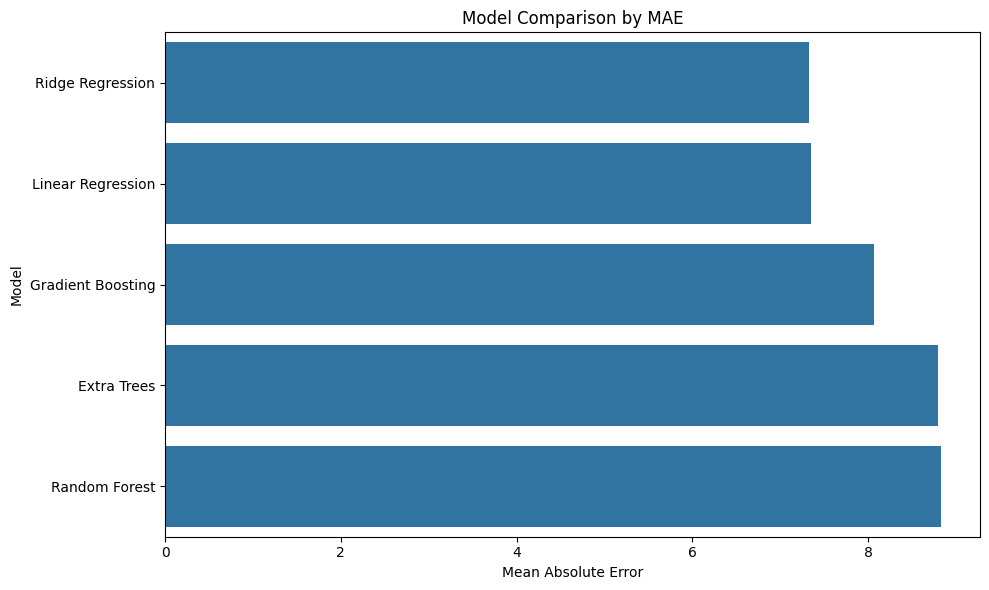

In [5]:
# Plot model comparison by MAE

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df,
    x="MAE",
    y="model"
)

plt.title("Model Comparison by MAE")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "model_comparison_mae.png", dpi=300)
plt.show()

In [6]:
# Select best model based on lowest MAE

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(results_df.iloc[0])

Best model: Ridge Regression
model    Ridge Regression
MAE              7.326032
RMSE             9.338117
R2               0.839369
Name: 1, dtype: object
